In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import os
from glob import glob
%matplotlib inline
import matplotlib.pyplot as plt
import seaborn as sns

##Import any other packages you may need here
from PIL import Image  # For image display and pixel analysis
from collections import Counter  # For co-occurrence analysis

# Inline plots
%matplotlib inline
sns.set(style="whitegrid")

EDA is open-ended, and it is up to you to decide how to look at different ways to slice and dice your data. A good starting point is to look at the requirements for the FDA documentation in the final part of this project to guide (some) of the analyses you do. 

This EDA should also help to inform you of how pneumonia looks in the wild. E.g. what other types of diseases it's commonly found with, how often it is found, what ages it affects, etc. 

Note that this NIH dataset was not specifically acquired for pneumonia. So, while this is a representation of 'pneumonia in the wild,' the prevalence of pneumonia may be different if you were to take only chest x-rays that were acquired in an ER setting with suspicion of pneumonia. 

Perform the following EDA:
* The patient demographic data such as gender, age, patient position,etc. (as it is available)
* The x-ray views taken (i.e. view position)
* The number of cases including: 
    * number of pneumonia cases,
    * number of non-pneumonia cases
* The distribution of other diseases that are comorbid with pneumonia
* Number of disease per patient 
* Pixel-level assessments of the imaging data for healthy & disease states of interest (e.g. histograms of intensity values) and compare distributions across diseases.

Note: use full NIH data to perform the first a few EDA items and use `sample_labels.csv` for the pixel-level assassements. 

Also, **describe your findings and how will you set up the model training based on the findings.**

In [2]:
## Below is some helper code to read data for you.
## Load NIH data
all_xray_df = pd.read_csv('/data/Data_Entry_2017.csv')
all_xray_df.sample(3)


,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11
14452,00003751_004.png,No Finding,4,3751,61,M,PA,2924,2948,0.143,0.143,NaN
34015,00008903_007.png,No Finding,7,8903,66,M,PA,2992,2991,0.143,0.143,NaN
94543,00024294_000.png,No Finding,0,24294,32,M,PA,2992,2991,0.143,0.143,NaN


In [3]:
from skimage import io

# Map image filenames to full paths
all_image_paths = {os.path.basename(x): x for x in 
                   glob(os.path.join('/data/images*', '*', '*.png'))}

# Attach full path to DataFrame
all_xray_df['Path'] = all_xray_df['Image Index'].map(all_image_paths.get)

# Check how many are found
print('Scans found:', len(all_image_paths), ', Total Headers:', all_xray_df.shape[0])

Scans found: 112120 , Total Headers: 112120


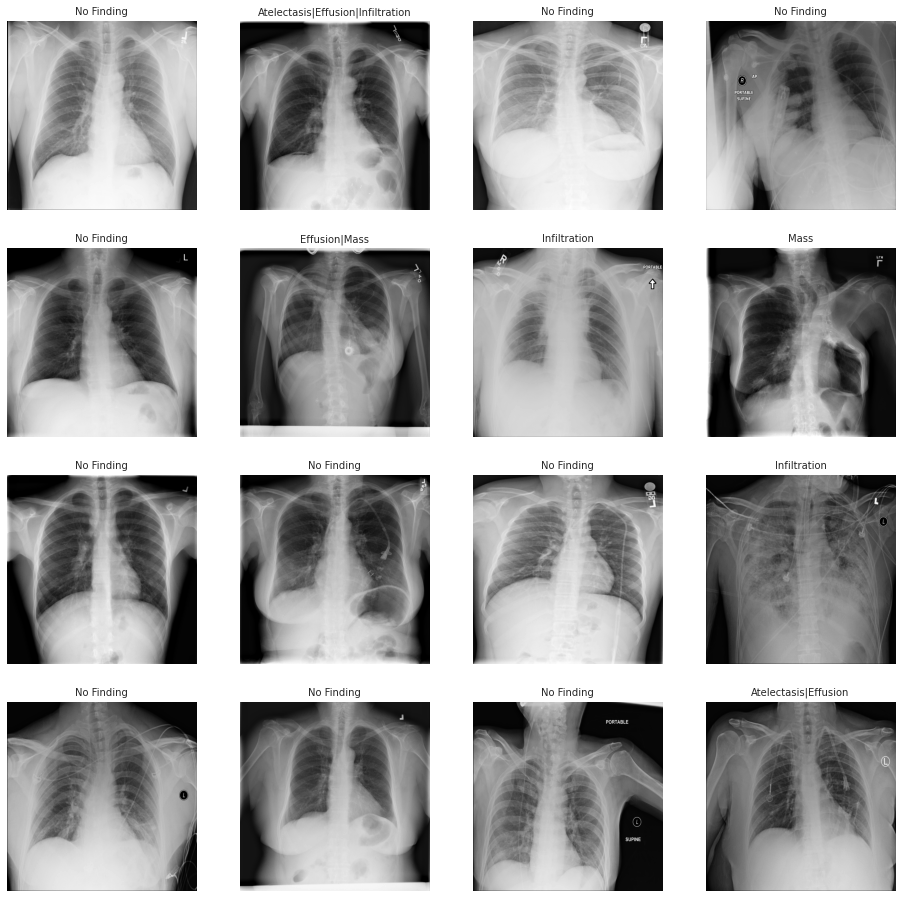

In [4]:
# Display 16 images with diagnosis labels
fig, m_axs = plt.subplots(4, 4, figsize=(16, 16))
m_axs = m_axs.flatten()
sample_df = all_xray_df.dropna(subset=['Path']).sample(16)

for i, (idx, row) in enumerate(sample_df.iterrows()):
    img = io.imread(row['Path'])
    m_axs[i].imshow(img, cmap='gray')
    m_axs[i].set_title(row['Finding Labels'], fontsize=10)
    m_axs[i].axis('off')

## 1: Demographics – age, gender, view Position

In [15]:
## EDA
# Todo 
# Quick check of the data
print("Dataset shape:", all_xray_df.shape)
all_xray_df.info()



Dataset shape: (112104, 14)
<class 'pandas.core.frame.DataFrame'>
Int64Index: 112104 entries, 0 to 112119
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Image Index                  112104 non-null  object 
 1   Finding Labels               112104 non-null  object 
 2   Follow-up #                  112104 non-null  int64  
 3   Patient ID                   112104 non-null  int64  
 4   Patient Age                  112104 non-null  int64  
 5   Patient Gender               112104 non-null  object 
 6   View Position                112104 non-null  object 
 7   OriginalImage[Width          112104 non-null  int64  
 8   Height]                      112104 non-null  int64  
 9   OriginalImagePixelSpacing[x  112104 non-null  float64
 10  y]                           112104 non-null  float64
 11  Unnamed: 11                  0 non-null       float64
 12  Path                         1

In [16]:
all_xray_df['Patient Age'].sample(10)

85272     17
105175    36
75385     56
107682    26
89202     28
62787     21
33404     53
74194     44
72216     63
5314      77
Name: Patient Age, dtype: int64

In [17]:
# Unusual ages
all_xray_df[(all_xray_df['Patient Age'] < 0) | (all_xray_df['Patient Age'] > 120)]

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Path,Has_Pneumonia


In [18]:
# Keep only rows with plausible age values
all_xray_df = all_xray_df[(all_xray_df['Patient Age'] >= 0) & (all_xray_df['Patient Age'] <= 120)]

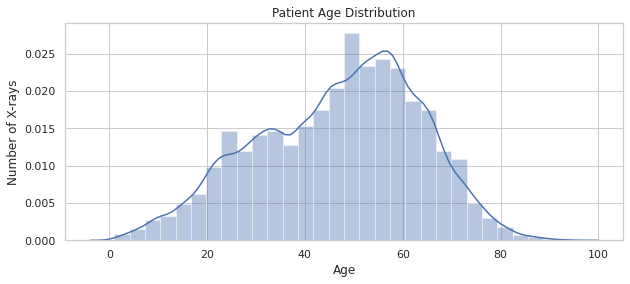

In [19]:
# Distribution of patient age
plt.figure(figsize=(10, 4))
sns.distplot(all_xray_df['Patient Age'], bins=30, kde=True, hist=True)
plt.title("Patient Age Distribution")
plt.xlabel("Age")
plt.ylabel("Number of X-rays")
plt.show()


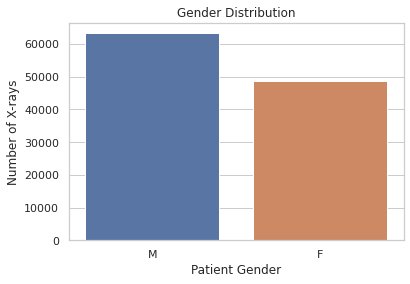

In [20]:
# Distribution of gender
plt.figure(figsize=(6, 4))
sns.countplot(data=all_xray_df, x='Patient Gender')
plt.title("Gender Distribution")
plt.ylabel("Number of X-rays")
plt.show()

There are more male patients in the dataset.

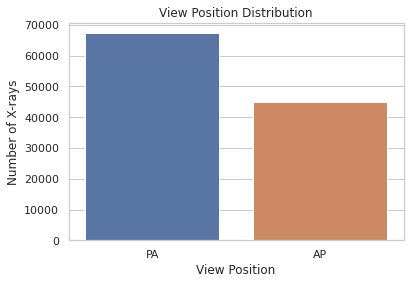

In [21]:
# Distribution of view positions
plt.figure(figsize=(6, 4))
sns.countplot(data=all_xray_df, x='View Position')
plt.title("View Position Distribution")
plt.ylabel("Number of X-rays")
plt.show()

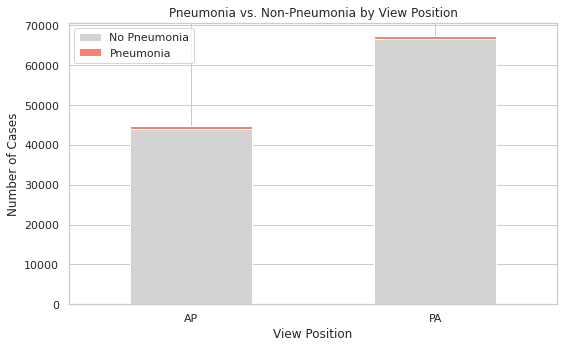

In [25]:
# Pneumonia counts by view position
pneumonia_by_view = all_xray_df.groupby(['View Position', 'Has_Pneumonia']).size().unstack(fill_value=0)

# Plot
pneumonia_by_view.plot(kind='bar', stacked=True, figsize=(8, 5), color=['lightgray', 'salmon'])
plt.title('Pneumonia vs. Non-Pneumonia by View Position')
plt.ylabel('Number of Cases')
plt.xticks(rotation=0)
plt.legend(['No Pneumonia', 'Pneumonia'])
plt.tight_layout()
plt.show()


In [26]:
# % of pneumonia cases within each view
pneumonia_percent_by_view = all_xray_df.groupby('View Position')['Has_Pneumonia'].mean() * 100
print(pneumonia_percent_by_view.round(2))

View Position
AP    1.79
PA    0.94
Name: Has_Pneumonia, dtype: float64


We observe a **higher proportion of pneumonia cases in X-rays taken in the AP view** (Anteroposterior - AP is often used when the patient can’t stand (e.g., ICU patients, people on stretchers)). This does not imply that the AP view is more effective at revealing pneumonia. Rather, it reflects a clinical reality: patients too weak or ill to stand are typically imaged in the AP view — and these patients are more likely to have pneumonia. This introduces a selection bias in the dataset, which must be considered when interpreting model performance or generalizing to new data. 

 ## 2: Pneumonia case distribution

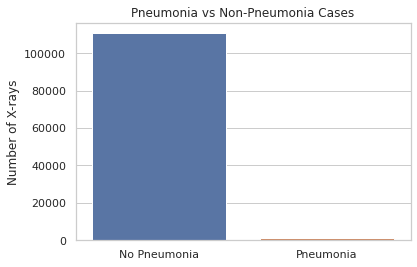

✅ Pneumonia cases: 1430
✅ Non-pneumonia cases: 110674


In [22]:
# Create a binary column: True if pneumonia is listed in 'Finding Labels'
all_xray_df['Has_Pneumonia'] = all_xray_df['Finding Labels'].apply(lambda x: 'Pneumonia' in x)

# Count pneumonia vs. non-pneumonia
pneumonia_counts = all_xray_df['Has_Pneumonia'].value_counts()

# Plot distribution
plt.figure(figsize=(6, 4))
sns.barplot(x=pneumonia_counts.index, y=pneumonia_counts.values)
plt.title('Pneumonia vs Non-Pneumonia Cases')
plt.xticks([0, 1], ['No Pneumonia', 'Pneumonia'])
plt.ylabel('Number of X-rays')
plt.show()

# Print the counts
print(f"✅ Pneumonia cases: {pneumonia_counts[True]}")
print(f"✅ Non-pneumonia cases: {pneumonia_counts[False]}")

No Pneumonia (0): 110674 cases (98.72%)
Pneumonia (1): 1430 cases (1.28%)


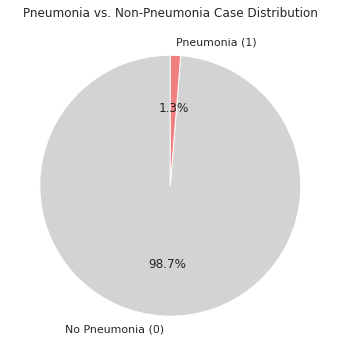

In [23]:
# Count pneumonia vs non-pneumonia cases
pneumonia_counts = all_xray_df['Has_Pneumonia'].value_counts().sort_index()

# Rename for clarity
labels = ['No Pneumonia (0)', 'Pneumonia (1)']
counts = pneumonia_counts.values
percentages = (counts / counts.sum()) * 100

# Display results
for label, count, pct in zip(labels, counts, percentages):
    print(f"{label}: {count} cases ({pct:.2f}%)")

# Optional: pie chart
plt.figure(figsize=(6, 6))
plt.pie(counts, labels=labels, autopct='%1.1f%%', startangle=90, colors=['lightgray', 'lightcoral'])
plt.title("Pneumonia vs. Non-Pneumonia Case Distribution")
plt.show()

We observe a significant class imbalance in the full dataset, with pneumonia cases representing only ~1.3% of all samples. To prevent our model from learning a biased decision boundary and ignoring pneumonia cases, we will create a balanced training and validation set by matching all pneumonia samples with an equal number of randomly selected non-pneumonia samples. This will enable fair training and evaluation of our model.

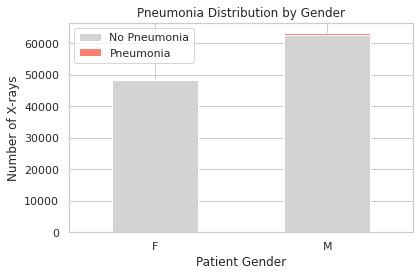

Patient Gender
F    1.22
M    1.32
Name: Has_Pneumonia, dtype: float64


In [27]:
# Compare pneumonia prevalence by gender

# Group by Gender and Pneumonia
gender_pneumonia = all_xray_df.groupby(['Patient Gender', 'Has_Pneumonia']).size().unstack(fill_value=0)

# Plot
gender_pneumonia.plot(kind='bar', stacked=True, figsize=(6, 4), color=['lightgray', 'salmon'])
plt.title('Pneumonia Distribution by Gender')
plt.ylabel('Number of X-rays')
plt.xticks(rotation=0)
plt.legend(['No Pneumonia', 'Pneumonia'])
plt.tight_layout()
plt.show()

# Percentage of pneumonia cases per gender
pneumonia_percent_gender = all_xray_df.groupby('Patient Gender')['Has_Pneumonia'].mean() * 100
print(pneumonia_percent_gender.round(2))

The percentage of pneumonia cases is slightly higher in males (1.32%) compared to females (1.22%), but the difference is minimal. This suggests that gender imbalance is not a major issue in the labeling of pneumonia within this dataset. However, model performance across genders should still be evaluated separately to ensure fairness in clinical deployment.

In [28]:
# Compare pneumonia prevalence by age group
# Create age bins
bins = [0, 18, 40, 60, 80, 120]
labels = ['0–18', '19–40', '41–60', '61–80', '81–120']
all_xray_df['Age Group'] = pd.cut(all_xray_df['Patient Age'], bins=bins, labels=labels)

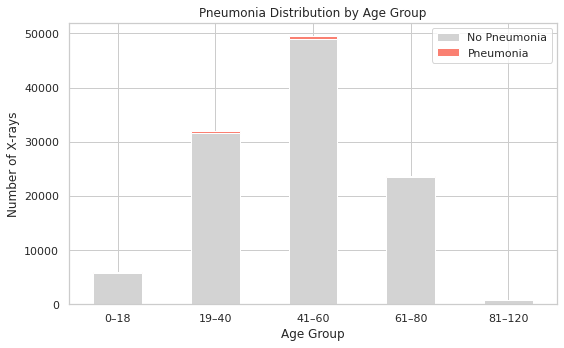

Age Group
0–18      1.95
19–40     1.46
41–60     1.11
61–80     1.21
81–120    1.14
Name: Has_Pneumonia, dtype: float64


In [29]:
# Pneumonia counts by age group
age_pneumonia = all_xray_df.groupby(['Age Group', 'Has_Pneumonia']).size().unstack(fill_value=0)

# Plot
age_pneumonia.plot(kind='bar', stacked=True, figsize=(8, 5), color=['lightgray', 'salmon'])
plt.title('Pneumonia Distribution by Age Group')
plt.ylabel('Number of X-rays')
plt.xticks(rotation=0)
plt.legend(['No Pneumonia', 'Pneumonia'])
plt.tight_layout()
plt.show()

# Percentage per age group
pneumonia_percent_age = all_xray_df.groupby('Age Group')['Has_Pneumonia'].mean() * 100
print(pneumonia_percent_age.round(2))

The highest rates in the 0–18 age category (1.95%). The prevalence then decreases through adulthood and rises slightly again in the 61–80 and 81–120 age groups. These trends may reflect real-world epidemiological patterns, as pneumonia is a leading cause of respiratory illness in both children and the elderly. However, they may also reflect sampling bias in the dataset or differences in clinical imaging practices across age groups. This emphasizes the importance of evaluating model performance across age subgroups in future validation steps.

## 3: Top co-occurring diseases

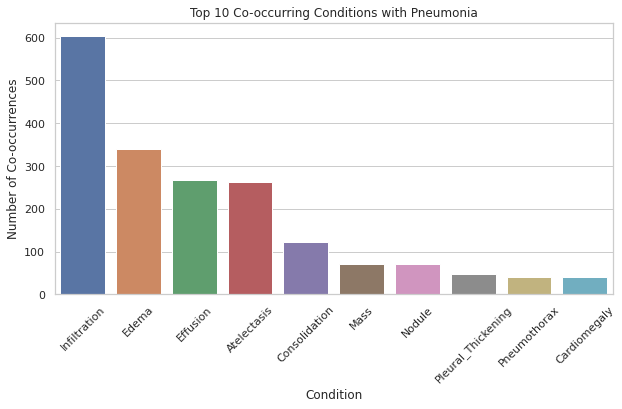

In [30]:
# Filter rows where pneumonia is present
pneumonia_cases = all_xray_df[all_xray_df['Has_Pneumonia'] == True]

# Extract co-occurring diseases (excluding 'Pneumonia' itself)
co_labels = []
for findings in pneumonia_cases['Finding Labels']:
    labels = findings.split('|')
    for label in labels:
        if label != 'Pneumonia':
            co_labels.append(label.strip())

# Count co-occurring diseases
from collections import Counter
co_counts = Counter(co_labels)

# Create DataFrame for plotting
co_df = pd.DataFrame(co_counts.items(), columns=['Condition', 'Count'])
co_df = co_df.sort_values(by='Count', ascending=False)

# Plot top 10 co-occurring conditions
plt.figure(figsize=(10, 5))
sns.barplot(data=co_df.head(10), x='Condition', y='Count')
plt.title('Top 10 Co-occurring Conditions with Pneumonia')
plt.xticks(rotation=45)
plt.ylabel('Number of Co-occurrences')
plt.show()

##### What % of pneumonia cases are pure (no comorbidities)?

In [35]:
pneumonia_cases = all_xray_df[all_xray_df['Has_Pneumonia'] == True].copy()

In [36]:
# Count pneumonia cases with and without other findings
pneumonia_cases.loc[:, 'Num Findings'] = pneumonia_cases['Finding Labels'].apply(lambda x: len(x.split('|')))

# Count pure pneumonia cases (no comorbidities)
pure_pneumonia = pneumonia_cases[pneumonia_cases['Num Findings'] == 1]

# Calculate percentage
pure_pct = len(pure_pneumonia) / len(pneumonia_cases) * 100
print(f"✅ Pure pneumonia cases (no comorbidities): {len(pure_pneumonia)}")
print(f"✅ Percentage of pneumonia cases without comorbidities: {pure_pct:.2f}%")


✅ Pure pneumonia cases (no comorbidities): 322
✅ Percentage of pneumonia cases without comorbidities: 22.52%


#### Pure vs. Comorbid Pneumonia Cases

Out of 1,430 pneumonia cases in the dataset, only 322 (22.5%) appeared without any other co-occurring conditions. This means that the vast majority of pneumonia cases (77.5%) were accompanied by at least one additional finding, such as effusion, consolidation, or infiltration. This is clinically realistic, as pneumonia often coexists with other thoracic abnormalities. However, it also presents a challenge for training diagnostic models, as the model must learn to detect pneumonia in the presence of overlapping or confounding conditions.


#### Heatmap of disease co-occurrence 

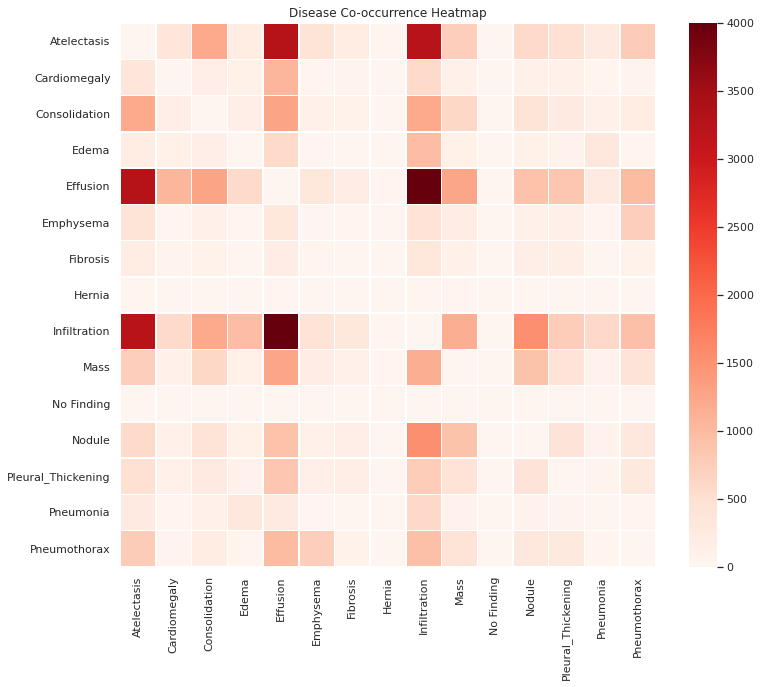

In [37]:
# Create binary flags for each disease
from sklearn.preprocessing import MultiLabelBinarizer

# Extract all labels
all_xray_df['Label List'] = all_xray_df['Finding Labels'].apply(lambda x: x.split('|'))
mlb = MultiLabelBinarizer()
label_matrix = mlb.fit_transform(all_xray_df['Label List'])

# Create DataFrame
labels_df = pd.DataFrame(label_matrix, columns=mlb.classes_)

# Co-occurrence matrix
co_matrix = labels_df.T.dot(labels_df)
np.fill_diagonal(co_matrix.values, 0)  # Remove self-counts

# Plot
plt.figure(figsize=(12, 10))
sns.heatmap(co_matrix, cmap='Reds', linewidths=0.5)
plt.title('Disease Co-occurrence Heatmap')
plt.show()

## 4: Number of diseases per patient (or per Image)

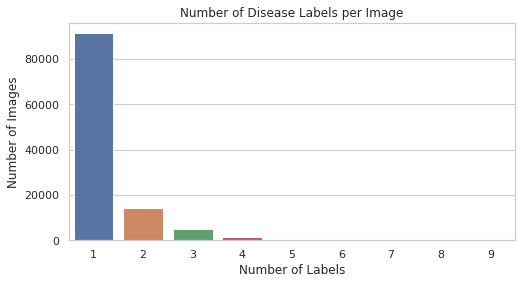

In [39]:
# Count how many labels each image has
all_xray_df['Num_Labels'] = all_xray_df['Finding Labels'].apply(lambda x: len(x.split('|')))

# Plot distribution
plt.figure(figsize=(8, 4))
sns.countplot(x='Num_Labels', data=all_xray_df)
plt.title('Number of Disease Labels per Image')
plt.xlabel('Number of Labels')
plt.ylabel('Number of Images')
plt.show()

##### Percentage of multi-disease cases

In [40]:
multi_label_counts = all_xray_df['Num_Labels'].value_counts().sort_index()
total_images = len(all_xray_df)
for num, count in multi_label_counts.items():
    pct = (count / total_images) * 100
    print(f"{num} labels: {count} images ({pct:.2f}%)")

1 labels: 91312 images (81.45%)
2 labels: 14302 images (12.76%)
3 labels: 4856 images (4.33%)
4 labels: 1247 images (1.11%)
5 labels: 301 images (0.27%)
6 labels: 67 images (0.06%)
7 labels: 16 images (0.01%)
8 labels: 1 images (0.00%)
9 labels: 2 images (0.00%)


#### Number of disease labels per image

We analyzed how many diagnostic labels were associated with each chest X-ray image. A total of 81.45% of images had a single condition label, while 18.55% had two or more. Although multi-label images are less common, they represent clinically complex cases where multiple thoracic findings coexist — such as effusion, consolidation, and pneumonia. The presence of up to 9 labels in a single image highlights the diagnostic richness and complexity of the dataset. This is an important consideration when training and evaluating models, especially since pneumonia often occurs as part of a broader pathology cluster.


##### Pie chart of single vs. multi-label cases

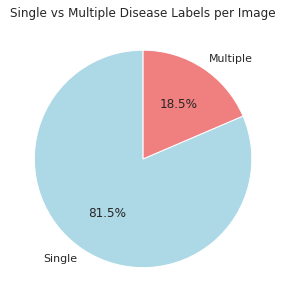

In [41]:
# Single vs multi-label
label_type = all_xray_df['Num_Labels'].apply(lambda x: 'Single' if x == 1 else 'Multiple')
label_type_counts = label_type.value_counts()

# Plot
plt.figure(figsize=(5, 5))
plt.pie(label_type_counts, labels=label_type_counts.index, autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightcoral'])
plt.title('Single vs Multiple Disease Labels per Image')
plt.show()

##### Boxplot of age vs number of labels

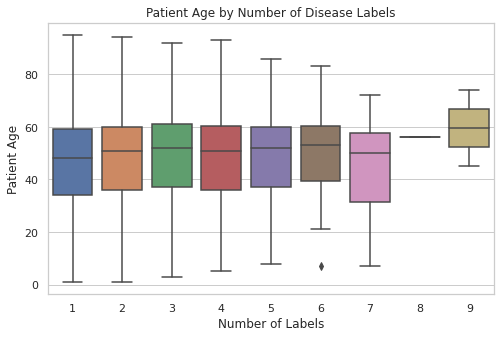

In [43]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Num_Labels', y='Patient Age', data=all_xray_df)
plt.title('Patient Age by Number of Disease Labels')
plt.xlabel('Number of Labels')
plt.ylabel('Patient Age')
plt.show()

## 5: Pixel-Level image assessment

In [74]:
# 1. Import everything we need
import pandas as pd
import numpy as np
import os
from glob import glob
from skimage import io
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [75]:
# 2. Load the labels
sample_df = pd.read_csv("sample_labels.csv")
print("✅ sample_labels.csv loaded:", sample_df.shape)

✅ sample_labels.csv loaded: (5606, 11)


In [76]:
# 3. Map image filenames to actual image paths
all_image_paths = {
    os.path.basename(x): x for x in glob('/data/images*/images/*.png')
}

print(f"✅ Scans found: {len(all_image_paths)}")

# 4. Add image paths to the dataframe
sample_df['path'] = sample_df['Image Index'].map(all_image_paths.get)

# 5. Drop rows where the image was not found
sample_df = sample_df.dropna(subset=['path'])
print(f"✅ Remaining rows after dropping missing images: {len(sample_df)}")

✅ Scans found: 112120
✅ Remaining rows after dropping missing images: 5606


In [78]:
# 6. Compute mean pixel intensity for each image
mean_intensities = []

for path in sample_df['path']:
    try:
        img = io.imread(path)
        mean_intensities.append(np.mean(img))
    except:
        mean_intensities.append(np.nan)

sample_df['Mean Intensity'] = mean_intensities

# Drop any rows that failed to load
sample_df = sample_df.dropna(subset=['Mean Intensity'])
print(f"✅ Final usable images: {len(sample_df)}")

✅ Final usable images: 5606


In [79]:
# 7. Select common diagnostic categories to compare
conditions_to_plot = ['No Finding', 'Infiltration', 'Effusion']

# Build a dictionary of intensities by label
intensity_dict = {}

for condition in conditions_to_plot:
    values = sample_df[sample_df['Finding Labels'] == condition]['Mean Intensity']
    if len(values) > 0:
        intensity_dict[condition] = values

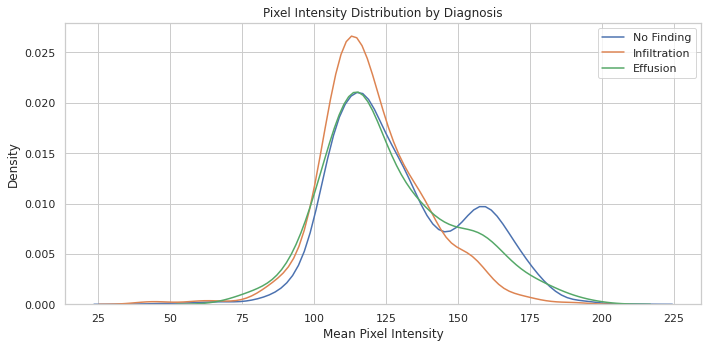

In [81]:
# 8. Plot intensity distributions
plt.figure(figsize=(10, 5))
for label, values in intensity_dict.items():
    sns.kdeplot(values, label=label)

plt.title("Pixel Intensity Distribution by Diagnosis")
plt.xlabel("Mean Pixel Intensity")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

##### Summary statistics per condition

In [82]:
# Summary statistics per condition
for label, values in intensity_dict.items():
    mean_val = np.mean(values)
    std_val = np.std(values)
    min_val = np.min(values)
    max_val = np.max(values)
    print(f"🔍 {label}:")
    print(f"   Mean intensity     = {mean_val:.2f}")
    print(f"   Std deviation      = {std_val:.2f}")
    print(f"   Min-Max range      = {min_val:.2f} – {max_val:.2f}")
    print()

🔍 No Finding:
   Mean intensity     = 129.35
   Std deviation      = 23.09
   Min-Max range      = 37.46 – 210.51

🔍 Infiltration:
   Mean intensity     = 120.26
   Std deviation      = 18.48
   Min-Max range      = 41.29 – 190.15

🔍 Effusion:
   Mean intensity     = 126.01
   Std deviation      = 22.54
   Min-Max range      = 75.48 – 193.43



##### Boxplot to visualize spread and outliers

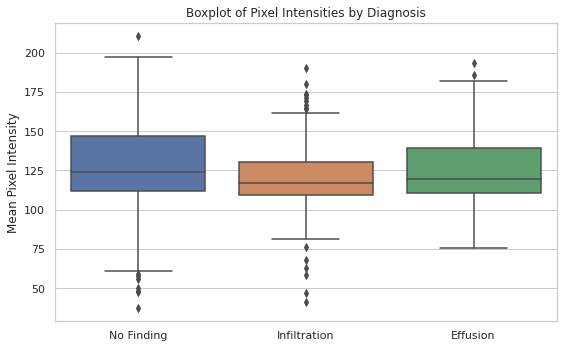

In [83]:
# Boxplot of intensity distributions
plt.figure(figsize=(8, 5))
sns.boxplot(data=[values for values in intensity_dict.values()], 
            orient='v')
plt.xticks(ticks=range(len(intensity_dict)), labels=intensity_dict.keys())
plt.ylabel("Mean Pixel Intensity")
plt.title("Boxplot of Pixel Intensities by Diagnosis")
plt.tight_layout()
plt.show()

#### Summary: Pixel-Level Assessment

Pixel-level intensity analysis was performed using chest X-rays in the `sample_labels.csv` subset. Each image’s mean pixel intensity was computed to observe differences across diagnostic categories.

##### Summary Statistics:
- **No Finding**  
  Mean: 129.35 — Std: 23.09 — Range: 37.46–210.51  
- **Infiltration**  
  Mean: 120.26 — Std: 18.48 — Range: 41.29–190.15  
- **Effusion**  
  Mean: 126.01 — Std: 22.54 — Range: 75.48–193.43

These findings suggest that:
- **"No Finding"** images are brighter and more evenly exposed.
- **"Infiltration"** shows reduced brightness, likely due to hazy densities.
- **"Effusion"** overlaps with normal exposure but trends lower.

This supports the use of **normalization** and **data augmentation** when training CNNs on this data.


## EDA Final Observations

- **Class imbalance**: Pneumonia accounts for ~1.3% of all images. Class balancing strategies (e.g. weighted loss, augmentation) are needed.
- **Demographic patterns**: Pneumonia was slightly more prevalent in males, in AP views, and had higher frequency in the 0–18 age group.
- **Comorbidities**: Only ~22% of pneumonia cases had pneumonia as the sole diagnosis. Many co-occur with Infiltration, Effusion, or Atelectasis.
- **Pixel-level variability** confirms clinical difficulty: even normal lungs have a wide intensity range.

These insights directly inform our training set curation, data normalization, and model validation strategy, including FDA submission planning.
